**- Load Data**

In [1]:
# prompt: open csv in my google drive

from google.colab import drive
import pandas as pd

# Mount your Google Drive
drive.mount('/content/drive')

# Replace 'your_file.csv' with the actual name of your CSV file
# Replace '/content/drive/MyDrive/path/to/your/file/' with the correct path to your file in Google Drive
file_path = '/content/drive/MyDrive/dataset_Q4_2024_12.csv'

try:
  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(file_path)


  # Now you can work with the DataFrame 'df'
  print(df.info())
  print(df.head()) # Print the first few rows to verify

except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
except pd.errors.EmptyDataError:
  print(f"Error: The CSV file at {file_path} is empty.")
except pd.errors.ParserError:
  print(f"Error: Could not parse the CSV file at {file_path}. Check its format.")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_ID    5000 non-null   object
 1   Customer_ID       5000 non-null   object
 2   Gender            5000 non-null   object
 3   Purchase_Date     5000 non-null   object
 4   Items_Purchased   5000 non-null   int64 
 5   Total_Spent       5000 non-null   int64 
 6   Category          2277 non-null   object
 7   Session_Duration  5000 non-null   int64 
 8   Hour              5000 non-null   int64 
 9   Has_Children      5000 non-null   int64 
 10  Payment_Method    2277 non-null   object
 11  Checkout_Time     5000 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 468.9+ KB
None
  Transaction_ID Customer_ID  Gender Purchase_Date  Items_Purchased  \
0             T1          C1  Female    2024-10-04                0   
1             T2        

**Noticed that Transaction_ID and Customer_ID look identical, do they both have only unique values?**

In [2]:
# prompt: check which columns have only unique values

unique_cols = []
for col in df.columns:
    if df[col].nunique() == len(df):
        unique_cols.append(col)
print("Columns with only unique values:", unique_cols)

Columns with only unique values: ['Transaction_ID', 'Customer_ID']


**Check for duplicates** if we didn't have Transaction_ID aor Customer_ID we wouldn't be able to identify duplicates properly.

In [3]:
# prompt: Check for duplicates in all columns
duplicate_rows = df[df.duplicated()]

# Print the duplicate rows (if any)
if not duplicate_rows.empty:
    print("Duplicate Rows:")
    print(duplicate_rows)
else:
    print("No duplicate rows found.")

# Remove duplicate rows (if needed)
# df.drop_duplicates(inplace=True) # Use inplace=True to modify the original dataframe directly

No duplicate rows found.


**Check for missing values**

In [4]:
# prompt: check for missing values

# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values)

# Check the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Value Percentage per Column:\n", missing_percentage)

Missing Values per Column:
 Transaction_ID         0
Customer_ID            0
Gender                 0
Purchase_Date          0
Items_Purchased        0
Total_Spent            0
Category            2723
Session_Duration       0
Hour                   0
Has_Children           0
Payment_Method      2723
Checkout_Time          0
dtype: int64

Missing Value Percentage per Column:
 Transaction_ID       0.00
Customer_ID          0.00
Gender               0.00
Purchase_Date        0.00
Items_Purchased      0.00
Total_Spent          0.00
Category            54.46
Session_Duration     0.00
Hour                 0.00
Has_Children         0.00
Payment_Method      54.46
Checkout_Time        0.00
dtype: float64


Many missing values in Category and Payment_Method, should check out what's happening in this variable.

*Many missing values, can't remove these rows so we need to investigate:*
- Are the rows with missing values always missing in both columns?
- Are they showing 0 in Items_Purchased and Total_Spent as well? (This could explain missing values as abandoned purchases)

In [5]:
# prompt: do all rows that have Payment method and Category as NaN also have Items_Purchased and Total_Spent amount of 0? if not, print exception rows then remove them

# Check if rows with NaN in 'Payment_Method' and 'Category' also have 0 in 'Items_Purchased' and 'Total_Spent'
exception_rows = df[df['Payment_Method'].isnull() & df['Category'].isnull()]
exception_rows = exception_rows[~((exception_rows['Items_Purchased'] == 0) & (exception_rows['Total_Spent'] == 0))]

if not exception_rows.empty:
    print("Exception Rows (NaN in Payment Method and Category but not 0 in Items Purchased and Total Spent):")
    print(exception_rows)

    # Remove the exception rows
    df = df[~df.index.isin(exception_rows.index)]
    print("Exception rows removed.")
else:
    print("No exception rows found.")

Exception Rows (NaN in Payment Method and Category but not 0 in Items Purchased and Total Spent):
     Transaction_ID Customer_ID  Gender Purchase_Date  Items_Purchased  \
498            T499        C499  Female    2024-11-22                0   
1750          T1751       C1751  Female    2024-11-24                0   
3406          T3407       C3407  Female    2024-10-30                0   
3811          T3812       C3812  Female    2024-11-17                0   
4298          T4299       C4299  Female    2024-12-05                0   

      Total_Spent Category  Session_Duration  Hour  Has_Children  \
498             9      NaN                 7     9             0   
1750         4889      NaN                16     2             1   
3406           10      NaN                 1    18             0   
3811            5      NaN                11     0             1   
4298           10      NaN                26     7             1   

     Payment_Method  Checkout_Time  
498        

**Bad data found:** rows with no Items_Purchased but a Total_Spent (impossible), small enough to remove.

**Back to question:**
- Are the rows with missing values always missing in both columns and have no Items/$ Spent?

In [6]:
# prompt: do all rows that have Payment method and Category as NaN also have Items_Purchased and Total_Spent amount of 0?

# Check if rows with NaN in 'Payment_Method' and 'Category' also have 0 in 'Items_Purchased' and 'Total_Spent'
exception_rows = df[df['Payment_Method'].isnull() & df['Category'].isnull()]
exception_rows = exception_rows[~((exception_rows['Items_Purchased'] == 0) & (exception_rows['Total_Spent'] == 0))]

if not exception_rows.empty:
    print("Rows with NaN in Payment Method and Category but not 0 in Items Purchased and Total Spent:")
    print(exception_rows)
    print("The answer is NO")
else:
    print("All rows with NaN in Payment Method and Category have 0 in Items Purchased and Total Spent.")
    print("The answer is YES")

All rows with NaN in Payment Method and Category have 0 in Items Purchased and Total Spent.
The answer is YES


Hypothesis: abandoned customers will have NaN in Category/Payment_Method and 0 in Total_Spent and Items_Purchased.
We need to apply this segmentation to dataset and see if distributions in variables supports this claim.

<ipython-input-7-30d39bb7448e>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Category'].fillna("abandoned", inplace=True)
<ipython-input-7-30d39bb7448e>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

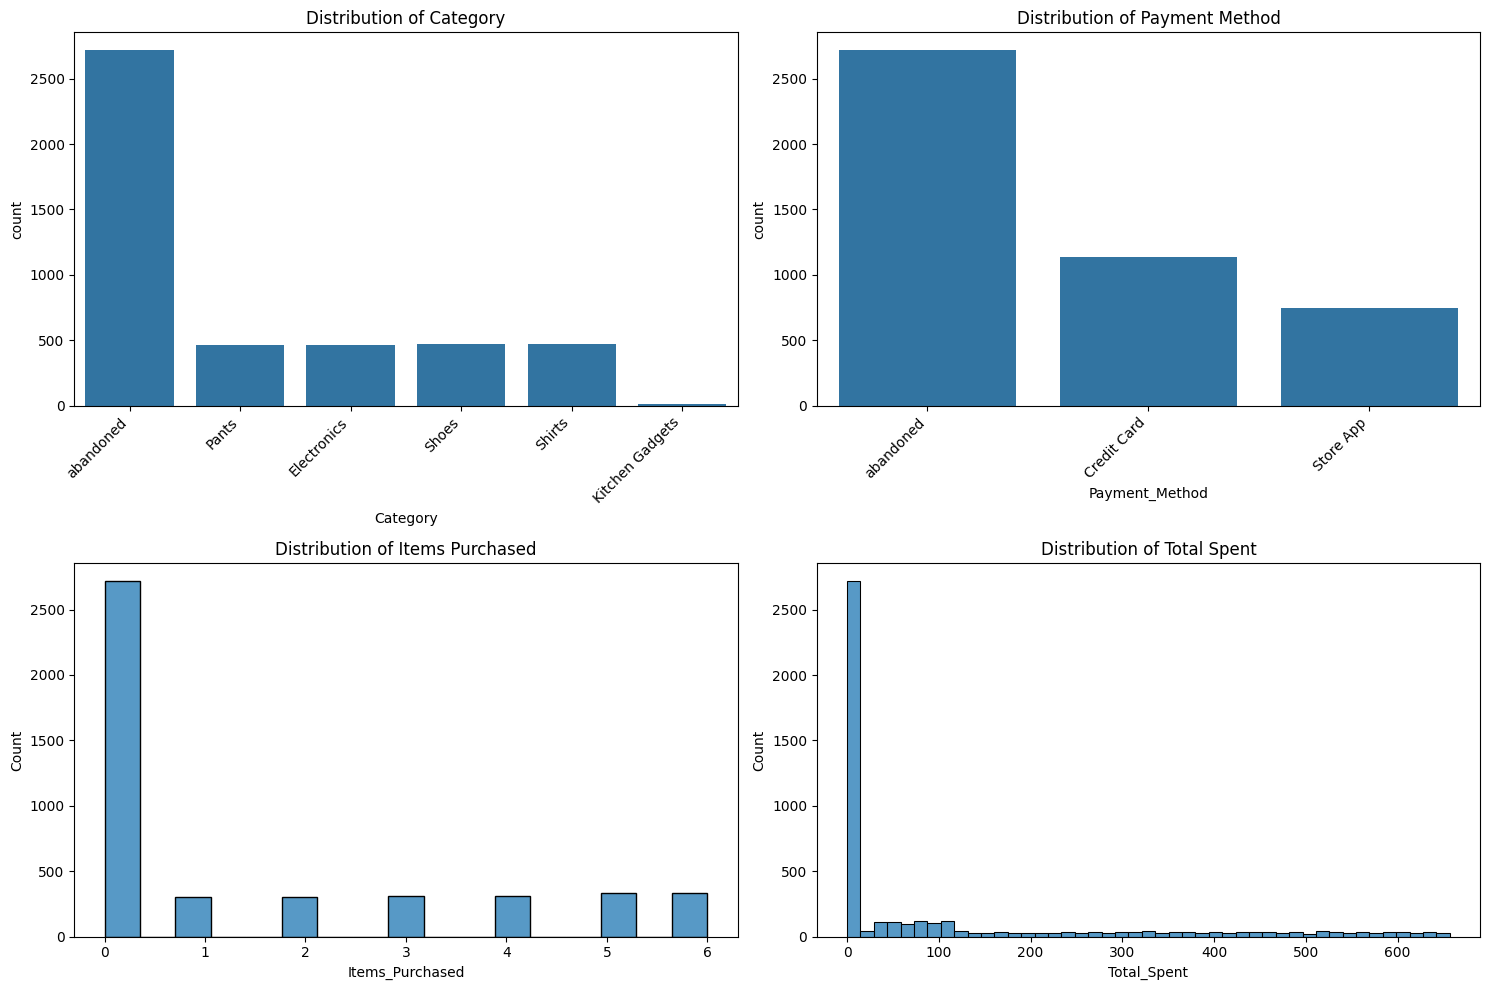

In [7]:
# prompt: label missing values as "abandoned" , graph distribution of Category, Payment_Method, Items_Purchased and Total_Spent, ignore outliers in Items_Purchased and Total_Spent

import matplotlib.pyplot as plt
import seaborn as sns

# Replace missing values with "Missing"
df['Category'].fillna("abandoned", inplace=True)
df['Payment_Method'].fillna("abandoned", inplace=True)


# Calculate the IQR for Items_Purchased and Total_Spent
Q1_items = df['Items_Purchased'].quantile(0.25)
Q3_items = df['Items_Purchased'].quantile(0.75)
IQR_items = Q3_items - Q1_items

Q1_total = df['Total_Spent'].quantile(0.25)
Q3_total = df['Total_Spent'].quantile(0.75)
IQR_total = Q3_total - Q1_total

# Define bounds for outlier removal
lower_bound_items = Q1_items - 1.5 * IQR_items
upper_bound_items = Q3_items + 1.5 * IQR_items

lower_bound_total = Q1_total - 1.5 * IQR_total
upper_bound_total = Q3_total + 1.5 * IQR_total

# Filter out outliers
df_filtered = df[
    (df['Items_Purchased'] >= lower_bound_items) & (df['Items_Purchased'] <= upper_bound_items) &
    (df['Total_Spent'] >= lower_bound_total) & (df['Total_Spent'] <= upper_bound_total)
]


# Create the distribution plots
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(x='Category', data=df_filtered)
plt.title('Distribution of Category')
plt.xticks(rotation=45, ha='right')


plt.subplot(2, 2, 2)
sns.countplot(x='Payment_Method', data=df_filtered)
plt.title('Distribution of Payment Method')
plt.xticks(rotation=45, ha='right')

plt.subplot(2, 2, 3)
sns.histplot(df_filtered['Items_Purchased'])
plt.title('Distribution of Items Purchased')


plt.subplot(2, 2, 4)
sns.histplot(df_filtered['Total_Spent'])
plt.title('Distribution of Total Spent')

plt.tight_layout()
plt.show()

Now we will segment all the data by taking the Items_Purchased variable before graphing distributions.

In [8]:
# prompt: create column called Converted, if Items_Purchased > 0, assign it 1, otherwise 0

# Assuming 'df' is your DataFrame from the previous code

df['Converted'] = df['Items_Purchased'].apply(lambda x: 1 if x > 0 else 0)

**Start comparing the variables distribution between abandoned vs. actual customers**

In [9]:
# prompt: split data into 2 sets, where Converted = 1 and where Converted = 0

# Assuming df is already defined from the previous code

# Split the DataFrame into two based on the 'Converted' column
converted = df[df['Converted'] == 1]
abandoned = df[df['Converted'] == 0]

# Now you have two separate DataFrames:
# converted_customers: Contains data for customers with Converted = 1
# abandoned_customers: Contains data for customers with Converted = 0

# You can now perform further analysis or operations on these separate DataFrames.
# For example, you can print their shapes to see how many rows each contains
print("Shape of converted DataFrame:", converted.shape)
print("Shape of abandoned DataFrame:", abandoned.shape)

Shape of converted DataFrame: (2277, 13)
Shape of abandoned DataFrame: (2718, 13)


In [12]:
palette = {
    0: 'tab:blue',
    1: 'tab:orange'
}

<ipython-input-13-8eaed7cb9651>:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


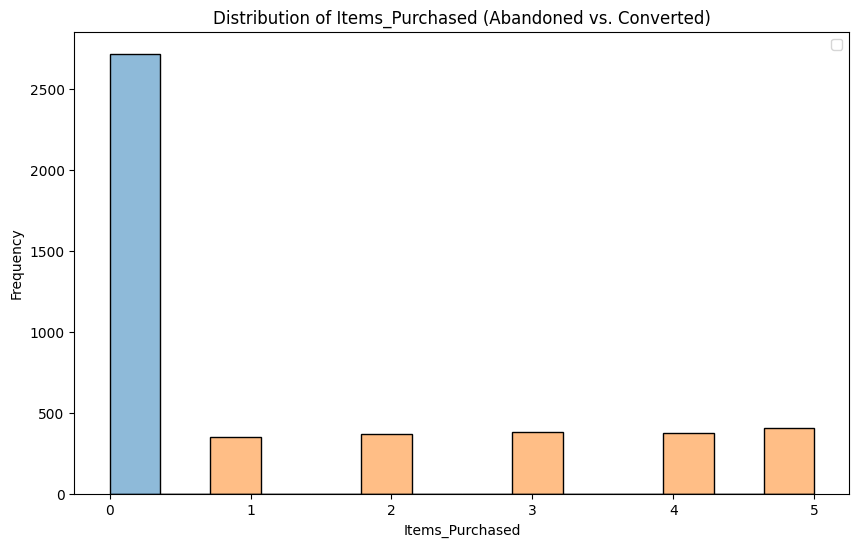

In [13]:
# prompt: plot distribution of Items_Purchased, abandoned vs converted, ignore values above 6

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df', 'converted', and 'abandoned' are already defined from the previous code

plt.figure(figsize=(10, 6))

# Plot distribution for converted customers
sns.histplot(data=df[df['Items_Purchased']<6], x='Items_Purchased', hue='Converted',palette=palette)

plt.title('Distribution of Items_Purchased (Abandoned vs. Converted)')
plt.xlabel('Items_Purchased')
plt.ylabel('Frequency')
plt.legend()
plt.show()

<ipython-input-14-3eba97fc9950>:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


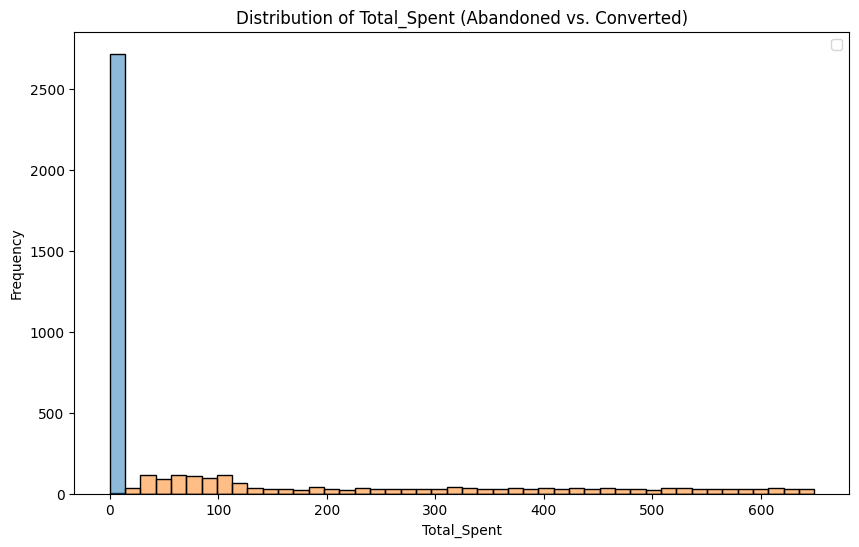

In [14]:
# prompt: plot distribution of Total_Spent in data, hue from Converted, ignore outliers for Total_Spent
# CODE OUTPUT WAS HAVING ISSUES SO I FOUND BETTER METHOD IN SEABORN DOCUMENTATION

plt.figure(figsize=(10, 6))

# Plot distribution
sns.histplot(data=df[df['Total_Spent']<650], x="Total_Spent", hue="Converted",palette=palette)

plt.title('Distribution of Total_Spent (Abandoned vs. Converted)')
plt.xlabel('Total_Spent')
plt.ylabel('Frequency')
plt.legend()
plt.show()

<ipython-input-15-3cf2e4bf9308>:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


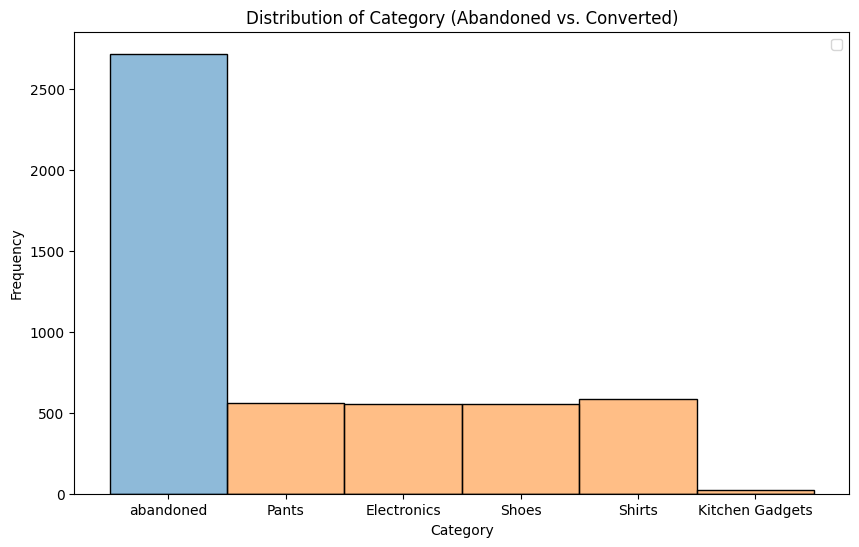

In [15]:
# NO PROMPT, JUST COPY/PASTED AND MODIFIED CODE

plt.figure(figsize=(10, 6))

# Plot distribution
sns.histplot(data=df, x="Category", hue="Converted",palette=palette)

plt.title('Distribution of Category (Abandoned vs. Converted)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.legend()
plt.show()

<ipython-input-16-8bfcdcd0d6dc>:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


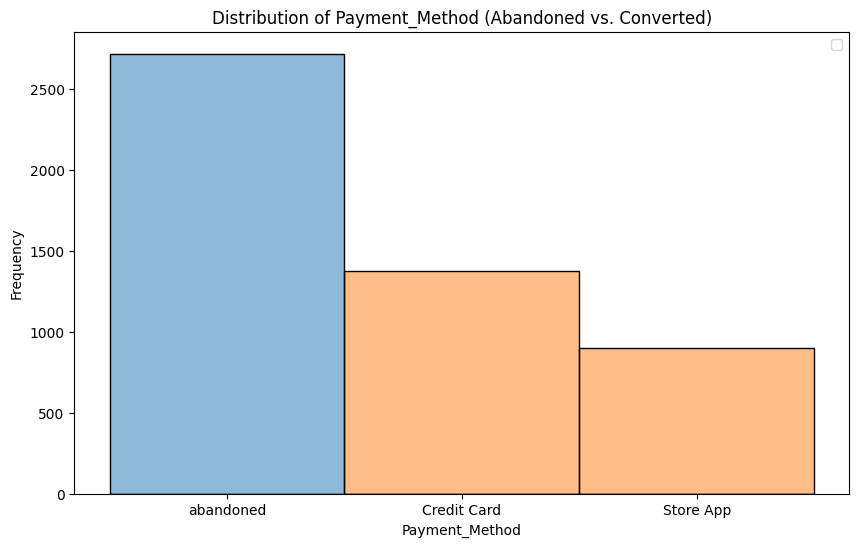

In [16]:
# NO PROMPT, JUST COPY/PASTED AND MODIFIED CODE

plt.figure(figsize=(10, 6))

# Plot distribution
sns.histplot(data=df, x="Payment_Method", hue="Converted",palette=palette)

plt.title('Distribution of Payment_Method (Abandoned vs. Converted)')
plt.xlabel('Payment_Method')
plt.ylabel('Frequency')
plt.legend()
plt.show()

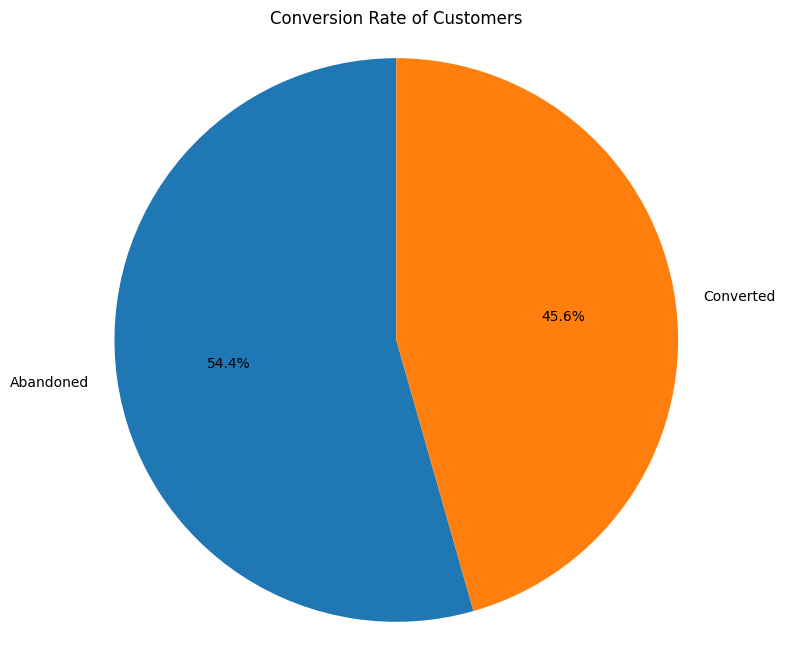

In [17]:
# prompt: show distribution of variable Converted in data with pie chart, call it Conversion Rate of Customers, label as Converted and Abandoned

import matplotlib.pyplot as plt

# Assuming df is already defined from the previous code

# Calculate the conversion rate
conversion_rate = df['Converted'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(conversion_rate, labels=['Abandoned', 'Converted'], autopct='%1.1f%%', startangle=90)
plt.title('Conversion Rate of Customers')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

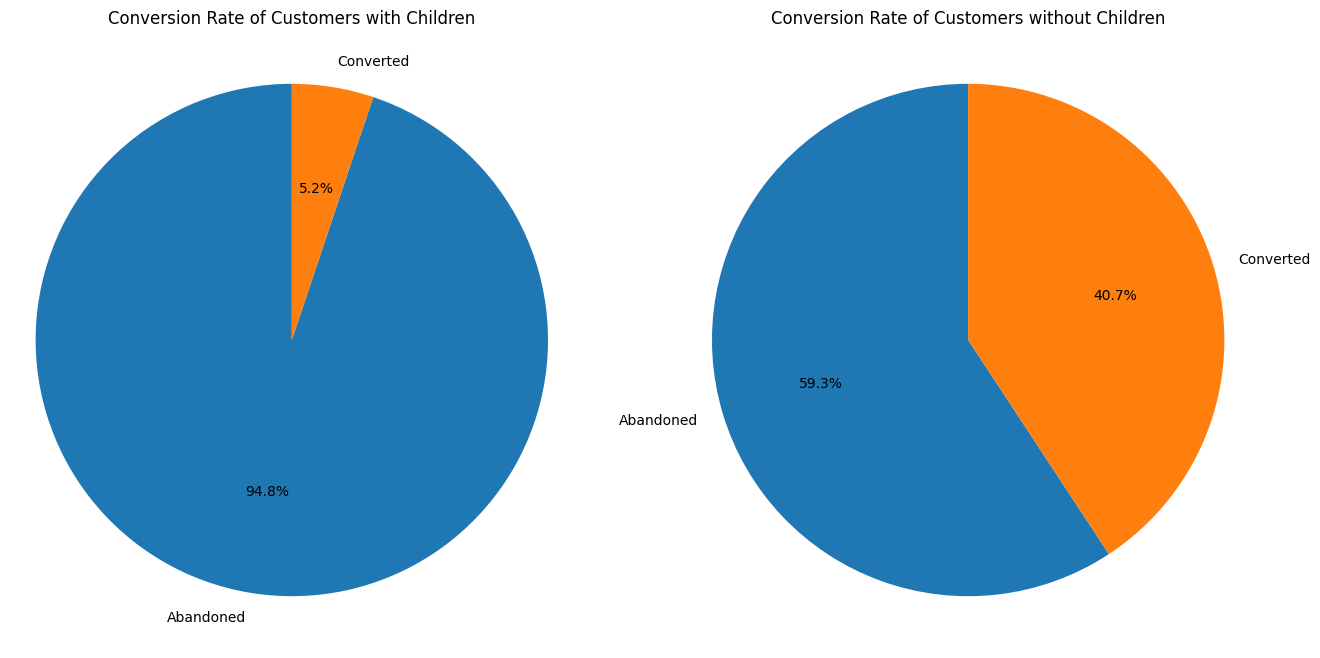

In [18]:
# prompt: split data into Has_Children = 0 and Has_Children = 1, then for each set show distribution of variable Converted in data with side by side pie charts, call it Conversion Rate of Customers, label as Converted and Abandoned

# Assuming df is already defined from the previous code

# Split the data into two groups based on 'Has_Children'
df_has_children = df[df['Has_Children'] == 1]
df_no_children = df[df['Has_Children'] == 0]

# Calculate conversion rates for each group
conversion_rate_has_children = df_has_children['Converted'].value_counts(normalize=True) * 100
conversion_rate_no_children = df_no_children['Converted'].value_counts(normalize=True) * 100

# Create subplots for side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pie chart for customers without children
axes[1].pie(conversion_rate_no_children, labels=['Abandoned', 'Converted'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Conversion Rate of Customers without Children')
axes[1].axis('equal')

# Pie chart for customers with children
axes[0].pie(conversion_rate_has_children, labels=['Abandoned', 'Converted'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Conversion Rate of Customers with Children')
axes[0].axis('equal')

plt.show()

In [19]:
# prompt: what percentage of customers Has_Children = 1?

# Assuming df is already defined from the previous code

# Calculate the percentage of customers with Has_Children = 0
percentage_children = (len(df[df['Has_Children'] == 1]) / len(df)) * 100

print(f"Percentage of customers with Has_Children = 0: {percentage_children:.2f}%")

Percentage of customers with Has_Children = 0: 25.27%


In [20]:
# NO PROMPT
x = len(df.query("Has_Children == 1 and Converted == 0")) / len(df) * 100
print(f"Percentage of customers with Has_Children = 1 and Abandoned: {x:.2f}%")

Percentage of customers with Has_Children = 1 and Abandoned: 23.96%


Above: Getting stats to put in problem/solution for market segment

**Apply solution 1, get conversion rate of our with children up to those without children, apply average total_spent to these rows to simulate our improved sales.**

In [21]:
# NO PROMPT - calculating how many "conversions" needed to simulate our first solution in action
y = len(df.query("Has_Children == 0 and Converted == 1")) / len(df.query("Has_Children == 0")) * 100
print(f"Conversion rate of customers without children: {y:.2f}%")

z = len(df.query("Has_Children == 1 and Converted == 1")) / len(df.query("Has_Children == 1")) * 100
print(f"Conversion rate of customers with children: {z:.2f}%")

d = y-z
print(f"Difference: {d:.2f}%")

conversions_needed = int(d / 100 * len(df.query("Has_Children == 1")))
print(f"Conversions needed: {conversions_needed}")

avg_spent = int(df.query("Converted == 1")["Total_Spent"].mean())
print(f"Average spent: {avg_spent}")

Conversion rate of customers without children: 59.26%
Conversion rate of customers with children: 5.15%
Difference: 54.10%
Conversions needed: 682
Average spent: 355


In [22]:
# prompt: make a copy of df called df_future
# find conversions_needed number of random rows in df_future where Has_Children = 1 and Converted = 0.
# in these rows change Converted = 1, Total_Spent = avg_spent, Checkout_Time a random number between 2 and 10
# show a sample of these rows after the change

import pandas as pd
import numpy as np

# Assuming df is already defined from the previous code and conversions_needed and avg_spent are calculated

df_future = df.copy()

# Find conversions_needed number of random rows where Has_Children = 1 and Converted = 0
rows_to_convert = df_future[(df_future['Has_Children'] == 1) & (df_future['Converted'] == 0)].sample(n=conversions_needed)

# Change Converted to 1, Total_Spent to avg_spent, and Checkout_Time to a random number between 2 and 10
df_future.loc[rows_to_convert.index, 'Converted'] = 1
df_future.loc[rows_to_convert.index, 'Total_Spent'] = avg_spent
df_future.loc[rows_to_convert.index, 'Checkout_Time'] = np.random.randint(2, 11, size=len(rows_to_convert))

# Show a sample of the modified rows
print(df_future.loc[rows_to_convert.index].sample(5))

     Transaction_ID Customer_ID  Gender Purchase_Date  Items_Purchased  \
2004          T2005       C2005  Female    2024-10-23                0   
3014          T3015       C3015  Female    2024-12-01                0   
2278          T2279       C2279  Female    2024-12-15                0   
215            T216        C216  Female    2024-11-14                0   
1955          T1956       C1956  Female    2024-11-25                0   

      Total_Spent   Category  Session_Duration  Hour  Has_Children  \
2004          355  abandoned                26    17             1   
3014          355  abandoned                12     2             1   
2278          355  abandoned                12     3             1   
215           355  abandoned                14     4             1   
1955          355  abandoned                16    23             1   

     Payment_Method  Checkout_Time  Converted  
2004      abandoned              6          1  
3014      abandoned              6    

In [23]:
# prompt: percentage of conversions_needed over all customers

percentage_conversions_needed = (conversions_needed / len(df)) * 100
print(f"Percentage of conversions needed over all customers: {percentage_conversions_needed:.2f}%")

Percentage of conversions needed over all customers: 13.65%


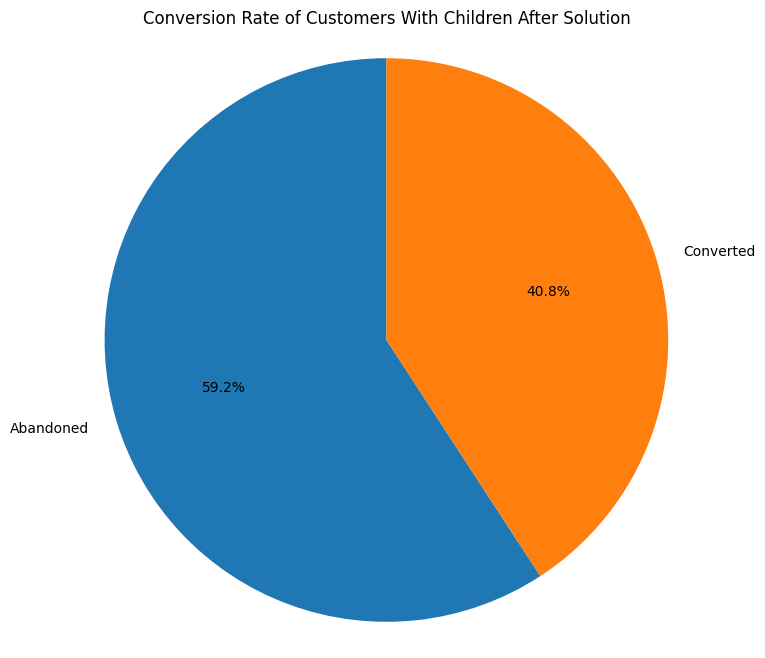

In [24]:
# prompt: show distribution of variable Converted in df_future (only rows where Has_Children = !) with pie chart, call it Conversion Rate of Customers With children, label as Converted and Abandoned

# Assuming df_future is already defined from the previous code

# Filter for rows where Has_Children == 1
df_future_children = df_future[df_future['Has_Children'] == 1]

# Calculate the conversion rate for customers with children
conversion_rate_children = df_future_children['Converted'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(conversion_rate_children, labels=['Abandoned', 'Converted'], autopct='%1.1f%%', startangle=90)
plt.title('Conversion Rate of Customers With Children After Solution')
plt.axis('equal')
plt.show()

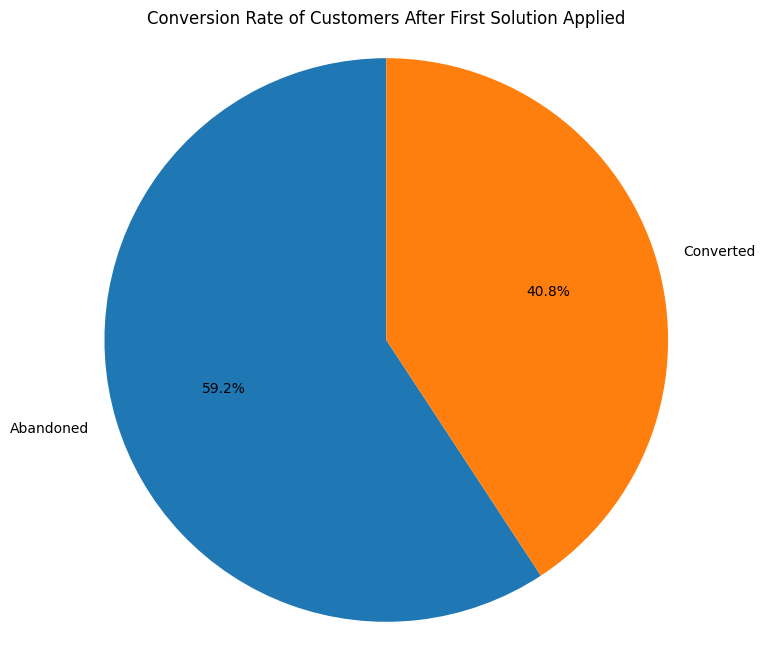

In [25]:
# prompt: show distribution of variable Converted in df_future with pie chart, call it Conversion Rate of Customers, label as Converted and Abandoned

import matplotlib.pyplot as plt

# Assuming df is already defined from the previous code

# Calculate the conversion rate
conversion_rate = df_future['Converted'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(conversion_rate, labels=['Abandoned', 'Converted'], autopct='%1.1f%%', startangle=90)
plt.title('Conversion Rate of Customers After First Solution Applied')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This wasn't a significant increase in Conversion Rate overall but customers with children have a decent conversion rate now

<ipython-input-26-59422df760af>:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


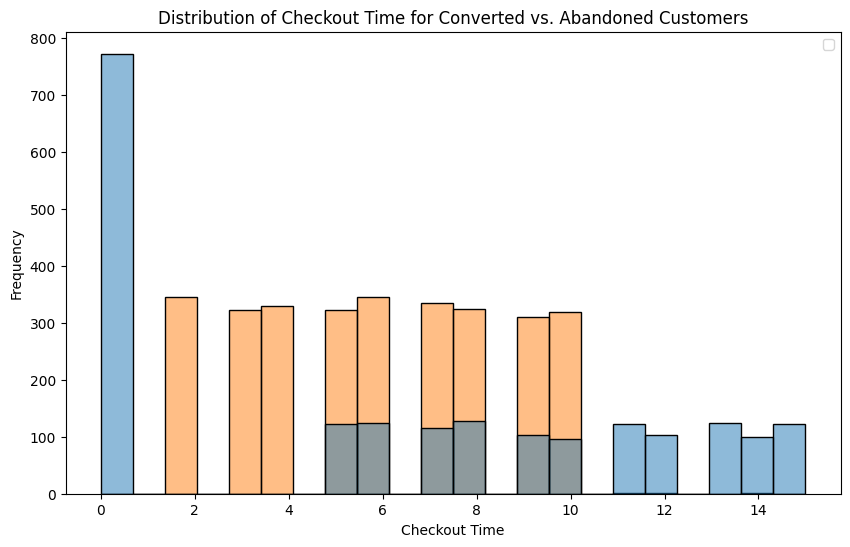

In [26]:
# prompt: distribution of Checkout_Time in df_future

import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(data=df_future, x='Checkout_Time',hue='Converted',alpha=0.5, palette=palette)
plt.xlabel('Checkout Time')
plt.ylabel('Frequency')
plt.title('Distribution of Checkout Time for Converted vs. Abandoned Customers')
plt.legend()
plt.show()


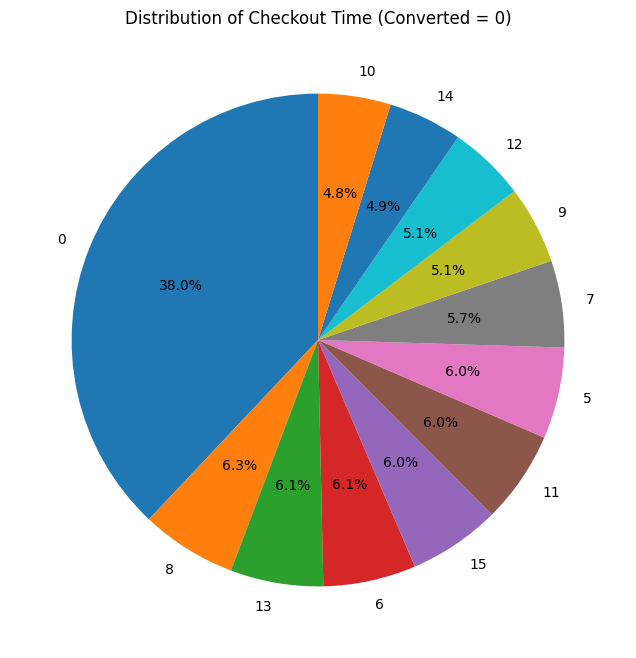

In [27]:
# prompt: distribution of Checkout_Time in df_future as a piechart, only Converted = 0

# Assuming df_future is already defined from the previous code

# Filter the DataFrame for Converted = 0
df_future_abandoned = df_future[df_future['Converted'] == 0]

# Create the pie chart
plt.figure(figsize=(8, 8))
df_future_abandoned['Checkout_Time'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Checkout Time (Converted = 0)')
plt.ylabel('') # Remove the y-axis label
plt.show()

In [28]:
# prompt: 6% of customers with Converted = 0 would be what percent in of all customers?

# Assuming df is your DataFrame from the previous code

# Calculate the total number of customers
total_customers = len(df)

# Calculate the number of customers with Converted = 0
abandoned_customers = len(df[df['Converted'] == 0])

# Calculate the number of customers representing 6% of those with Converted = 0
six_percent_abandoned = int(0.06 * abandoned_customers)

# Calculate the percentage of all customers that this represents
percentage_of_all = (six_percent_abandoned / total_customers) * 100

print(f"6% of customers with Converted = 0 represents {percentage_of_all:.2f}% of all customers.")

6% of customers with Converted = 0 represents 3.26% of all customers.


After 4 min, we are losing ~3% of customers each minute

In [29]:
# prompt: percentage of customers with Checkout_Time >4 and Converted = 0 over all customers

# Assuming df is your DataFrame from the previous code

# Calculate the total number of customers
total_customers = len(df)

# Filter for customers with Checkout_Time > 4 and Converted = 0
filtered_customers = df[(df['Checkout_Time'] > 4) & (df['Converted'] == 0)]

# Calculate the number of filtered customers
num_filtered_customers = len(filtered_customers)

# Calculate the percentage
percentage = (num_filtered_customers / total_customers) * 100

print(f"Percentage of customers with Checkout_Time > 4 and Converted = 0: {percentage:.2f}%")

Percentage of customers with Checkout_Time > 4 and Converted = 0: 33.23%


Calculated percentage of customers that we are converting with solution above ^

**Apply Solution 2 and graph results**

In [30]:
# prompt: make copy of df_future called df_solutions
# take all rows where Converted = 0 in df_solutions and Checkout_Time > 4, change Converted = 1 and Total_Spent = avg_spent
# show a sample of these rows to show they were changed

df_solutions = df_future.copy()

# Filter for rows where Converted = 0 and Checkout_Time > 4
rows_to_change = df_solutions[(df_solutions['Converted'] == 0) & (df_solutions['Checkout_Time'] > 4)]

# Change Converted and Total_Spent for those rows
df_solutions.loc[rows_to_change.index, 'Converted'] = 1
df_solutions.loc[rows_to_change.index, 'Total_Spent'] = avg_spent

# Show a sample of the changed rows
print(df_solutions.loc[rows_to_change.index].sample(5))

     Transaction_ID Customer_ID  Gender Purchase_Date  Items_Purchased  \
4147          T4148       C4148  Female    2024-11-21                0   
164            T165        C165    Male    2024-11-17                0   
741            T742        C742  Female    2024-11-22                0   
4192          T4193       C4193  Female    2024-12-12                0   
3847          T3848       C3848  Female    2024-10-06                0   

      Total_Spent   Category  Session_Duration  Hour  Has_Children  \
4147          355  abandoned                 1     5             0   
164           355  abandoned                 2    14             0   
741           355  abandoned                12     3             1   
4192          355  abandoned                 1     7             0   
3847          355  abandoned                 2    14             0   

     Payment_Method  Checkout_Time  Converted  
4147      abandoned             12          1  
164       abandoned             15    

In [31]:
# prompt: take all rows where Checkout_Time > 4, change Checkout_Time = random int between 1-4
# show a sample of these rows to show they were changed

# Assuming df_solutions is your DataFrame from the previous code

# Filter rows where Checkout_Time > 4
rows_to_modify = df_solutions[df_solutions['Checkout_Time'] > 4]

# Generate random integers between 1 and 4 for Checkout_Time
new_checkout_times = np.random.randint(1, 5, size=len(rows_to_modify))

# Update Checkout_Time in the DataFrame
df_solutions.loc[rows_to_modify.index, 'Checkout_Time'] = new_checkout_times

# Display a sample of the modified rows
print(df_solutions.query("Checkout_Time > 1 and Checkout_Time <5").sample(5))

     Transaction_ID Customer_ID  Gender Purchase_Date  Items_Purchased  \
2122          T2123       C2123  Female    2024-12-18                0   
534            T535        C535  Female    2024-12-18                3   
3717          T3718       C3718    Male    2024-10-22                0   
1671          T1672       C1672  Female    2024-10-06                5   
1778          T1779       C1779  Female    2024-12-11                5   

      Total_Spent     Category  Session_Duration  Hour  Has_Children  \
2122          355    abandoned                13    10             1   
534           363  Electronics                32     8             0   
3717          355    abandoned                27     9             0   
1671          501  Electronics                32     8             0   
1778          411  Electronics                15     6             0   

     Payment_Method  Checkout_Time  Converted  
2122      abandoned              3          1  
534       Store App       

<ipython-input-32-9fa7372c43c4>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


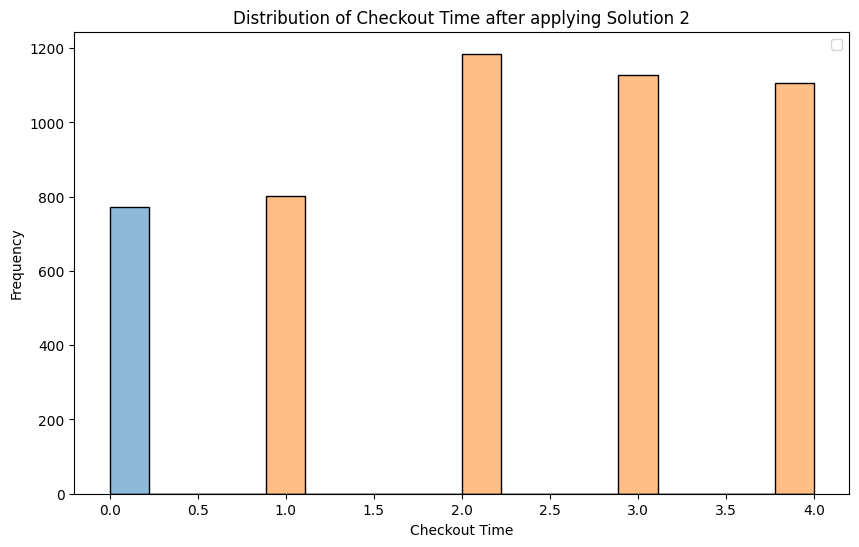

In [32]:
# prompt: graph distribution of Checkout_Time in df_solutions

# Assuming df_solutions is already defined from the previous code

plt.figure(figsize=(10, 6))
sns.histplot(data=df_solutions, x='Checkout_Time', hue='Converted', alpha=0.5, palette=palette)
plt.xlabel('Checkout Time')
plt.ylabel('Frequency')
plt.title('Distribution of Checkout Time after applying Solution 2')
plt.legend()
plt.show()

In [36]:
# prompt: calculate conversion rate for df_solutions, show them in dataframe, compare sum of Total_Spent between df and df_solutions, call it Total Sales
# NOTE: Manually modified string title of "Conversion Rate" because it was actually returning abandonement rate

# Calculate the conversion rate for df_solutions
conversion_rate_solutions = df_solutions['Converted'].value_counts(normalize=True) * 100

# Create a DataFrame to display the conversion rates
conversion_rates_df = pd.DataFrame({
    'Solution': ['Original Data', 'After Solutions'],
    'Abandonement Rate': [df['Converted'].value_counts(normalize=True).iloc[1] * 100, conversion_rate_solutions.iloc[1]]
})

print(conversion_rates_df)

# Compare the sum of Total_Spent between df and df_solutions
total_sales_original = df['Total_Spent'].sum()
total_sales_solutions = df_solutions['Total_Spent'].sum()

# Create a DataFrame to display the total sales
total_sales_comparison = pd.DataFrame({
    'Dataset': ['Original Data', 'After Solutions'],
    'Total Sales': [total_sales_original, total_sales_solutions]
})

total_sales_comparison

          Solution  Abandonement Rate
0    Original Data          45.585586
1  After Solutions          15.475475


,Dataset,Total Sales
0,Original Data,808567
1,After Solutions,1499042


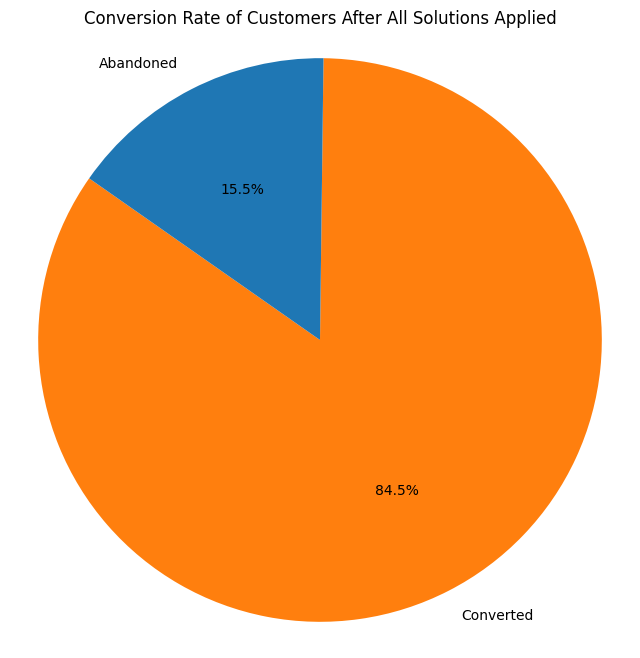

In [52]:
# prompt: graph conversion rate of df_solutions in pie chart

import matplotlib.pyplot as plt

# Assuming df_solutions is already defined from the previous code

# Calculate the conversion rate
conversion_rate_solutions = df_solutions['Converted'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(conversion_rate_solutions, labels=['Converted','Abandoned'], autopct='%1.1f%%', startangle=145, colors=['tab:orange', 'tab:blue'])
plt.title('Conversion Rate of Customers After All Solutions Applied')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()